In [1]:
#importing librarires
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split


In [2]:
#preprocessing the data
from sklearn.model_selection import train_test_split
import shutil
from PIL import Image
import os

# Define paths
dataset_dir =r"C:\Users\HP\Desktop\Art Style\dataset\dataset_updated\training_set"
train_dir = "data/train"
val_dir = "data/val"
test_dir = "data/test"

# Create folders for train, val, and test
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Function to validate images
def is_valid_image(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify()  # Verify that the file is not corrupted
            img = Image.open(image_path)
            if img.mode != "RGB":  # Check if the image is in RGB format
                return False
        return True
    except Exception as e:
        print(f"Invalid image {image_path}: {e}")
        return False

# Split data
for style in os.listdir(dataset_dir):
    style_dir = os.path.join(dataset_dir, style)
    os.makedirs(os.path.join(train_dir, style), exist_ok=True)
    os.makedirs(os.path.join(val_dir, style), exist_ok=True)
    os.makedirs(os.path.join(test_dir, style), exist_ok=True)

    images = [
        img for img in os.listdir(style_dir) 
        if img.lower().endswith(('.png', '.jpg', '.jpeg')) and is_valid_image(os.path.join(style_dir, img))
    ]
    print(f"Processing style: {style} | Valid images: {len(images)}")

    # Split into train, val, and test sets
    train, test = train_test_split(images, test_size=0.2, random_state=42)
    train, val = train_test_split(train, test_size=0.2, random_state=42)

    # Copy images to respective directories
    for img in train:
        shutil.copy(os.path.join(style_dir, img), os.path.join(train_dir, style))
    for img in val:
        shutil.copy(os.path.join(style_dir, img), os.path.join(val_dir, style))
    for img in test:
        shutil.copy(os.path.join(style_dir, img), os.path.join(test_dir, style))





Processing style: drawings | Valid images: 1107
Invalid image C:\Users\HP\Desktop\Art Style\dataset\dataset_updated\training_set\engraving\249.jpg: cannot identify image file 'C:\\Users\\HP\\Desktop\\Art Style\\dataset\\dataset_updated\\training_set\\engraving\\249.jpg'
Invalid image C:\Users\HP\Desktop\Art Style\dataset\dataset_updated\training_set\engraving\304.jpg: cannot identify image file 'C:\\Users\\HP\\Desktop\\Art Style\\dataset\\dataset_updated\\training_set\\engraving\\304.jpg'
Invalid image C:\Users\HP\Desktop\Art Style\dataset\dataset_updated\training_set\engraving\356.jpg: cannot identify image file 'C:\\Users\\HP\\Desktop\\Art Style\\dataset\\dataset_updated\\training_set\\engraving\\356.jpg'
Processing style: engraving | Valid images: 725
Invalid image C:\Users\HP\Desktop\Art Style\dataset\dataset_updated\training_set\iconography\331.jpg: cannot identify image file 'C:\\Users\\HP\\Desktop\\Art Style\\dataset\\dataset_updated\\training_set\\iconography\\331.jpg'
Invalid 

In [3]:
#Normalize and Augment Images
datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=20,           # Rotate images randomly
    width_shift_range=0.2,       # Shift images horizontally
    height_shift_range=0.2,      # Shift images vertically
    horizontal_flip=True,        # Flip images horizontally
    validation_split=0.2         # Split into training and validation
)

# Training and validation generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),  # Resize all images to 128x128
    batch_size=32,
    class_mode='categorical'  # Multi-class classification
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)


Found 4909 images belonging to 5 classes.
Found 1229 images belonging to 5 classes.


In [4]:
#Build the Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load VGG16 without the top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze the base model

# Build a custom classifier
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax')  # Number of styles
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [5]:
#Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Increase epochs for better results
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=val_generator.samples // val_generator.batch_size
)


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 604s 4s/step - accuracy: 0.6541 - loss: 1.0257 - val_accuracy: 0.8174 - val_loss: 0.4863
Epoch 2/10
  1/153 ━━━━━━━━━━━━━━━━━━━━ 8:14 3s/step - accuracy: 0.7812 - loss: 0.6456

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


153/153 ━━━━━━━━━━━━━━━━━━━━ 124s 797ms/step - accuracy: 0.7812 - loss: 0.6456 - val_accuracy: 0.8150 - val_loss: 0.4795
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 645s 4s/step - accuracy: 0.8142 - loss: 0.5062 - val_accuracy: 0.8405 - val_loss: 0.4265
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 135s 866ms/step - accuracy: 0.7812 - loss: 0.5431 - val_accuracy: 0.8339 - val_loss: 0.4334
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 595s 4s/step - accuracy: 0.8321 - loss: 0.4592 - val_accuracy: 0.8248 - val_loss: 0.4438
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 120s 769ms/step - accuracy: 0.8125 - loss: 0.4689 - val_accuracy: 0.8322 - val_loss: 0.4421
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 591s 4s/step - accuracy: 0.8295 - loss: 0.4584 - val_accuracy: 0.8544 - val_loss: 0.4218
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 120s 768ms/step - accuracy: 0.8438 - loss: 0.7527 - val_accuracy: 0.8528 - val_loss: 0.4041
Epoch 9/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 592s 4s/step - accuracy: 0.8426 - loss: 0.4287 - val_acc

In [6]:
#Save the Trained Model
model.save("trained_model.keras")  # Save in the native Keras format


In [7]:
#Loading a Saved Model
from tensorflow.keras.models import load_model

model = load_model("trained_model.keras")  # Load the native Keras format model


In [8]:
model.save("trained_model.keras", include_optimizer=False)


In [9]:
#Evaluate the Model
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Found 1537 images belonging to 5 classes.
49/49 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.8639 - loss: 0.3407
Test Accuracy: 85.36%


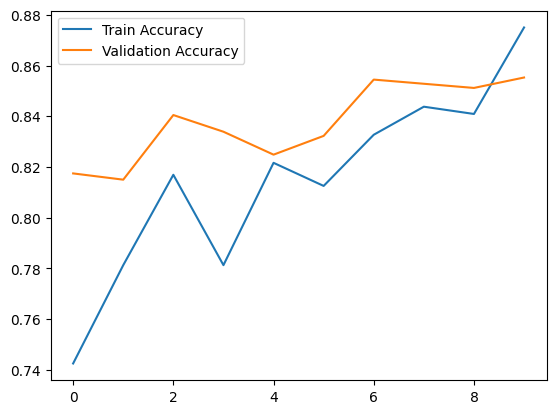

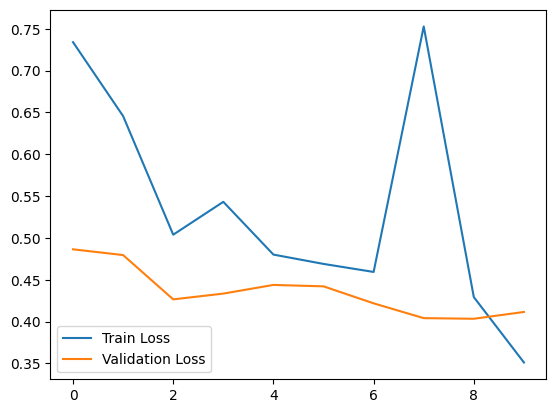

In [10]:
#Visualize Training Results
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [12]:
#Save the Model
model.save('art_style_classifier.keras')


In [ ]:
pip install ten